In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from cenpy import products, explorer

In [29]:
df = pd.read_csv('../lib/data-public/oca_addresses_with_ct.csv')

In [30]:
df['geoid'] = df['geoid'].astype(str)
df.value_counts('geoid')

geoid
36081045500    9066
36029017400    5531
36029004402    5329
36081033404    5270
36083041102    4908
               ... 
36081024600       1
36067012800       1
36067012700       1
36057072200       1
36019100200       1
Name: count, Length: 4014, dtype: int64

### Grab census data

In [34]:
cenn = products.APIConnection("ACSDT5Y2021") 
cols = {
    "B25071_001E": "MEDIAN GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME" # IN THE PAST 12 MONTHS
    }

b2 = cenn.query(cols.keys(), 
    geo_unit='tract',
    geo_filter={"state": '36'})

b2['GEOID'] = b2.apply(lambda r: f"{r['state']}{r['county']}{r['tract']}", axis = 1)
b2['B25071_001E'] = b2['B25071_001E'].astype(float) / 100

b2 = b2[b2['B25071_001E'] > 0]

b2 = b2.rename(columns = cols)[['GEOID']+ list(cols.values())]
b2

,GEOID,MEDIAN GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME
0,36001000100,0.288
1,36001000201,0.382
2,36001000202,0.426
3,36001000301,0.377
4,36001000302,0.354
...,...,...
5406,36123150301,0.247
5407,36123150302,0.439
5408,36123150400,0.325
5409,36123150501,0.192


In [35]:
cenn = products.APIConnection("ACSDP5Y2021")

#https://api.census.gov/data/2019/acs/acs5/profile/groups/DP04.html
cols = {
    "DP02_0001E": "HOUSEHOLDS",
    "DP04_0047E":"Occupied housing units!!Renter-occupied"
    }

d2 = cenn.query(cols.keys(), 
    geo_unit='tract',
    geo_filter={"state": '36'})

d2['GEOID'] = d2.apply(lambda r: f"{r['state']}{r['county']}{r['tract']}", axis = 1)
d2['DP02_0001E'] = d2['DP02_0001E'].astype(int)
d2['DP04_0047E'] = d2['DP04_0047E'].astype(int)

d2 = d2[d2['DP04_0047E'] > 0]
d2 = d2.rename(columns = cols)[['GEOID']+ list(cols.values())]
d2

,GEOID,HOUSEHOLDS,Occupied housing units!!Renter-occupied
0,36001000100,825,507
1,36001000201,1222,950
2,36001000202,1119,756
3,36001000301,1141,821
4,36001000302,1845,1261
...,...,...,...
5406,36123150301,887,108
5407,36123150302,719,84
5408,36123150400,1229,370
5409,36123150501,1008,333


In [36]:
acs = pd.merge(b2, d2, on = 'GEOID', how = 'inner')
acs.sample(10)

,GEOID,MEDIAN GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME,HOUSEHOLDS,Occupied housing units!!Renter-occupied
3577,36081054800,0.199,694,112
494,36007014500,0.510,1432,193
4939,36119008404,0.290,2038,1297
4760,36113072001,0.312,885,287
2037,36055009301,0.316,906,748
1539,36047044000,0.336,857,551
1529,36047043000,0.405,1277,1037
3714,36081081400,0.465,1026,297
356,36005037100,0.314,1683,1528
2903,36067010700,0.293,936,360


### Join and normalize 

In [43]:
table = pd.DataFrame(df.value_counts('geoid')).reset_index().merge(
    acs, left_on = 'geoid', right_on = 'GEOID')

table['cases per 100 units'] = (table['count'] / table['Occupied housing units!!Renter-occupied']) * 100

(0.0, 400.0)

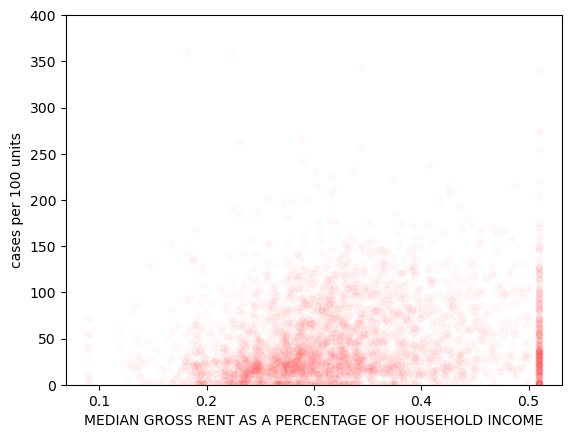

In [50]:
fig = plt.figure()
ax = plt.subplot(111)

table.plot.scatter('MEDIAN GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME','cases per 100 units', 
                   c= '#ff080805', ax = ax)


ax.set_ylim(0,400)

In [62]:
table_with_links = table[['geoid','count','Occupied housing units!!Renter-occupied','cases per 100 units']].copy().sort_values('cases per 100 units', ascending = False)
table_with_links['link'] = 'https://censusreporter.org/profiles/14000US' + table_with_links['geoid']

table_with_links

,geoid,count,Occupied housing units!!Renter-occupied,cases per 100 units,link
1231,36061011300,341,20,1705.000000,https://censusreporter.org/profiles/14000US360...
753,36061010900,599,68,880.882353,https://censusreporter.org/profiles/14000US360...
4,36083041102,4908,701,700.142653,https://censusreporter.org/profiles/14000US360...
1,36029017400,5531,817,676.988984,https://censusreporter.org/profiles/14000US360...
9,36001000202,3935,756,520.502646,https://censusreporter.org/profiles/14000US360...
...,...,...,...,...,...
3828,36111953400,1,1220,0.081967,https://censusreporter.org/profiles/14000US361...
3771,36055013902,1,1317,0.075930,https://censusreporter.org/profiles/14000US360...
3750,36001013602,1,1328,0.075301,https://censusreporter.org/profiles/14000US360...
3809,36067011102,1,1494,0.066934,https://censusreporter.org/profiles/14000US360...


In [63]:
table_with_links.to_csv('../lib/data-public/table_with_links.csv', index = False)